# Sales Forecasting – End-to-End Walkthrough
Demonstrates EDA → Feature Engineering → Model Training → Selection → Forecast

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
import warnings; warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
plt.rcParams.update({'figure.figsize':(14,5),'axes.spines.top':False,'axes.spines.right':False})
DATA_PATH = '../data/Forecasting_Case-_Study.xlsx'

## 1 · Load & Explore

In [2]:
from src.data_loader import load_raw
df = load_raw(DATA_PATH)
print(df.shape); print(df.dtypes)
df.head()

(8084, 4)
state               object
date        datetime64[ns]
sales              float64
category            object
dtype: object


,state,date,sales,category
0,Alabama,2019-01-12,109574036.0,Beverages
1,Arizona,2019-01-12,109101594.6,Beverages
2,Arkansas,2019-01-12,58049432.2,Beverages
3,California,2019-01-12,444766890.6,Beverages
4,Colorado,2019-01-12,89816716.3,Beverages


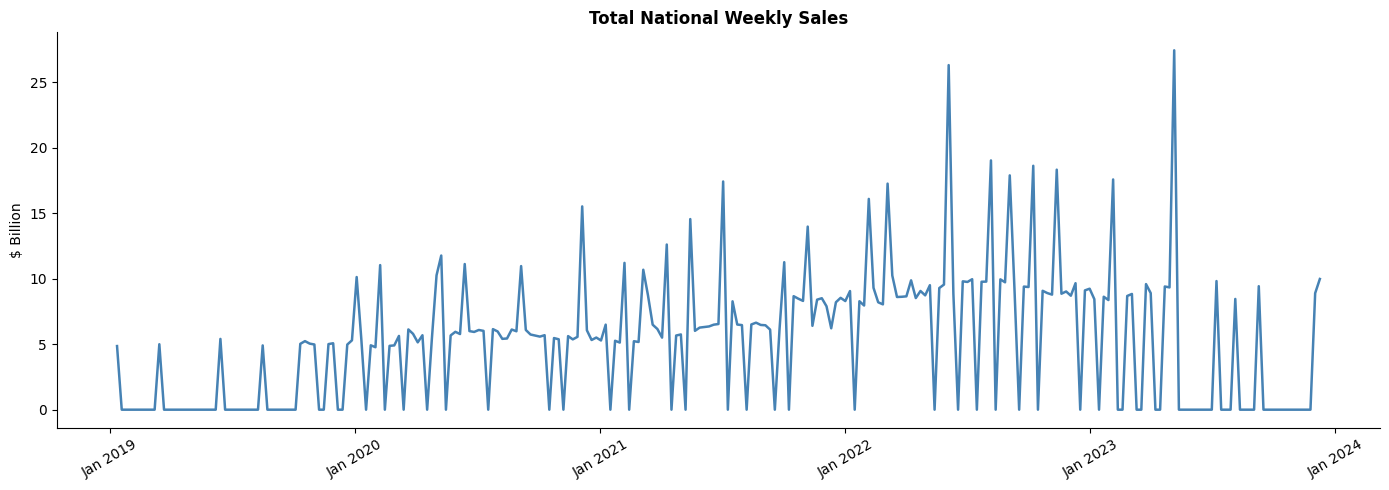

In [3]:
national = df.groupby('date')['sales'].sum().resample('W-SAT').sum()
fig, ax = plt.subplots()
ax.plot(national.index, national.values/1e9, lw=1.8, color='steelblue')
ax.set_title('Total National Weekly Sales', fontweight='bold'); ax.set_ylabel('$ Billion')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y')); plt.xticks(rotation=30)
plt.tight_layout(); plt.savefig('../artifacts/national_sales.png',dpi=150); plt.show()

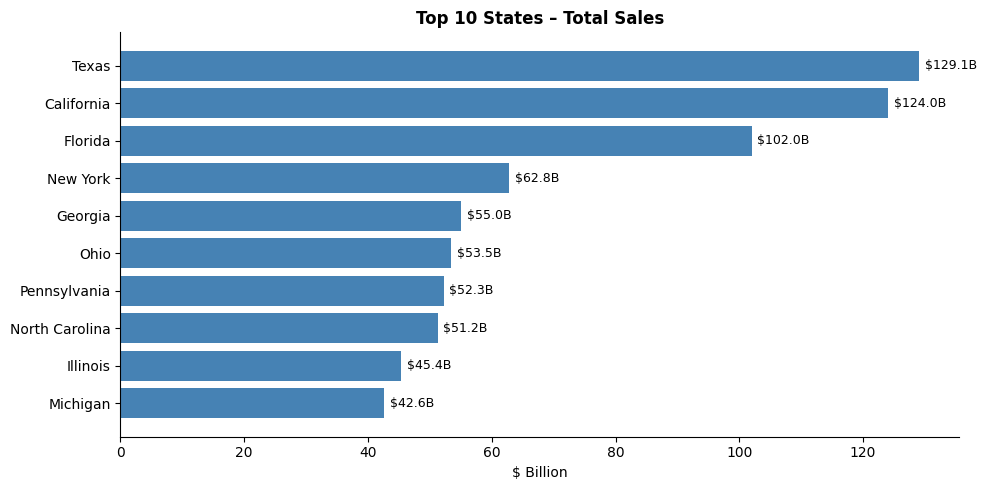

In [4]:
top10 = df.groupby('state')['sales'].sum().nlargest(10)
fig, ax = plt.subplots(figsize=(10,5))
bars = ax.barh(top10.index[::-1], top10.values[::-1]/1e9, color='steelblue')
ax.bar_label(bars, fmt='$%.1fB', padding=4, fontsize=9)
ax.set_title('Top 10 States – Total Sales', fontweight='bold'); ax.set_xlabel('$ Billion')
plt.tight_layout(); plt.savefig('../artifacts/top10_states.png',dpi=150); plt.show()

## 2 · Feature Engineering

In [5]:
from src.data_loader import prepare_state_series, train_val_split
from src.feature_engineering import build_features
STATE = 'California'
ts = prepare_state_series(df, STATE)
train, val = train_val_split(ts, val_weeks=8)
feat_df = build_features(train)
print(feat_df.shape)
feat_df.head()

(197, 22)


,sales,lag_1,lag_7,lag_4,lag_13,lag_52,roll_mean_4w,roll_std_4w,roll_mean_8w,roll_std_8w,...,week_of_year,month,quarter,year,sin_week,cos_week,sin_month,cos_month,day_of_week,holiday_flag
date,,,,,,,,,,,,,,,,,,,,,
2020-01-11,5.179173e+08,9.349359e+08,4.867944e+08,4.667213e+08,497063951.7,4.447669e+08,5.886459e+08,2.312304e+08,5.354649e+08,1.618189e+08,...,2,1,1,2020,0.239316,0.970942,0.500000,0.866025,5,0
2020-01-18,4.786961e+08,5.179173e+08,4.772410e+08,4.614615e+08,504318965.7,4.500814e+08,6.014449e+08,2.235204e+08,5.385646e+08,1.611279e+08,...,3,1,1,2020,0.354605,0.935016,0.500000,0.866025,5,0
2020-01-25,4.394750e+08,4.786961e+08,4.719811e+08,4.914647e+08,491957816.8,4.553958e+08,6.057535e+08,2.200620e+08,5.375524e+08,1.615246e+08,...,4,1,1,2020,0.464723,0.885456,0.500000,0.866025,5,1
2020-02-01,4.503363e+08,4.394750e+08,4.667213e+08,9.349359e+08,505768871.6,4.607103e+08,5.927561e+08,2.303567e+08,5.328316e+08,1.640708e+08,...,5,2,1,2020,0.568065,0.822984,0.866025,0.500000,5,0
2020-02-08,1.039646e+09,4.503363e+08,4.614615e+08,5.179173e+08,499444033.9,4.660248e+08,4.716062e+08,3.502287e+07,5.301260e+08,1.653908e+08,...,6,2,1,2020,0.663123,0.748511,0.866025,0.500000,5,0


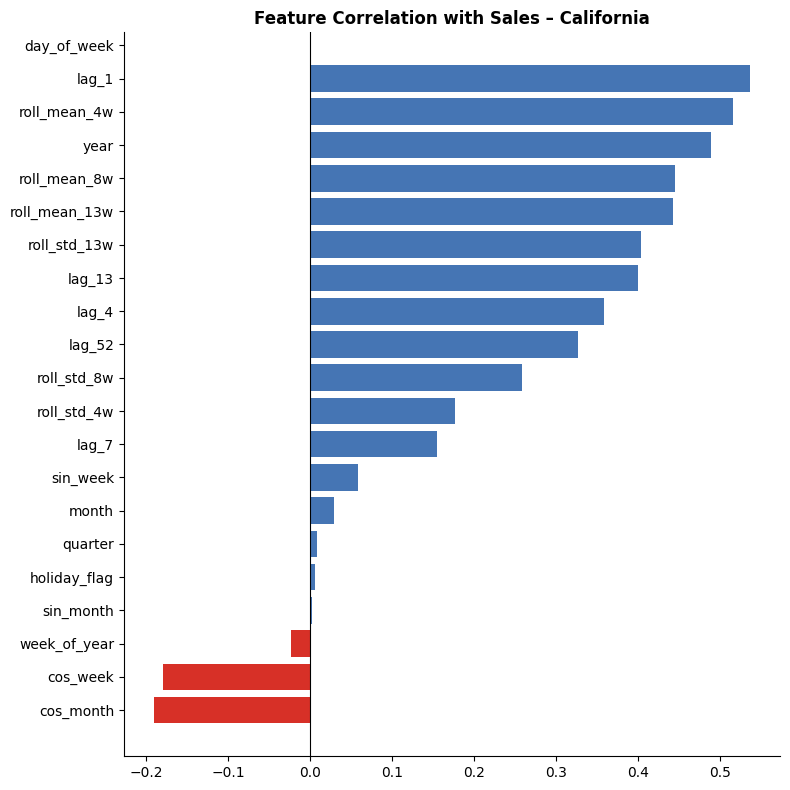

In [6]:
corrs = feat_df.corr()['sales'].drop('sales').sort_values()
fig, ax = plt.subplots(figsize=(8,8))
colors = ['#d73027' if v<0 else '#4575b4' for v in corrs.values]
ax.barh(corrs.index, corrs.values, color=colors)
ax.axvline(0, color='black', lw=0.8)
ax.set_title(f'Feature Correlation with Sales – {STATE}', fontweight='bold')
plt.tight_layout(); plt.savefig('../artifacts/feature_correlation.png',dpi=150); plt.show()

## 3 · Train & Compare All Models

In [12]:
from src.model_selector import ModelSelector
selector = ModelSelector(n_forecast=8)
result = selector.run(STATE, train, val)
print(f'Best: {result.best_model}')
pd.DataFrame(result.all_metrics).T.round(2)

17:20:15 - cmdstanpy - INFO - Chain [1] start processing
17:20:15 - cmdstanpy - INFO - Chain [1] done processing


Best: SARIMA


,rmse,mae,mape,r2
SARIMA,1.354388e+08,1.324946e+08,15.51,-30.75
Prophet,2.584442e+08,2.526265e+08,29.60,-114.62
XGBoost,1.643945e+08,1.412657e+08,16.47,-45.78
LSTM,1.834479e+08,1.818457e+08,21.23,-57.25


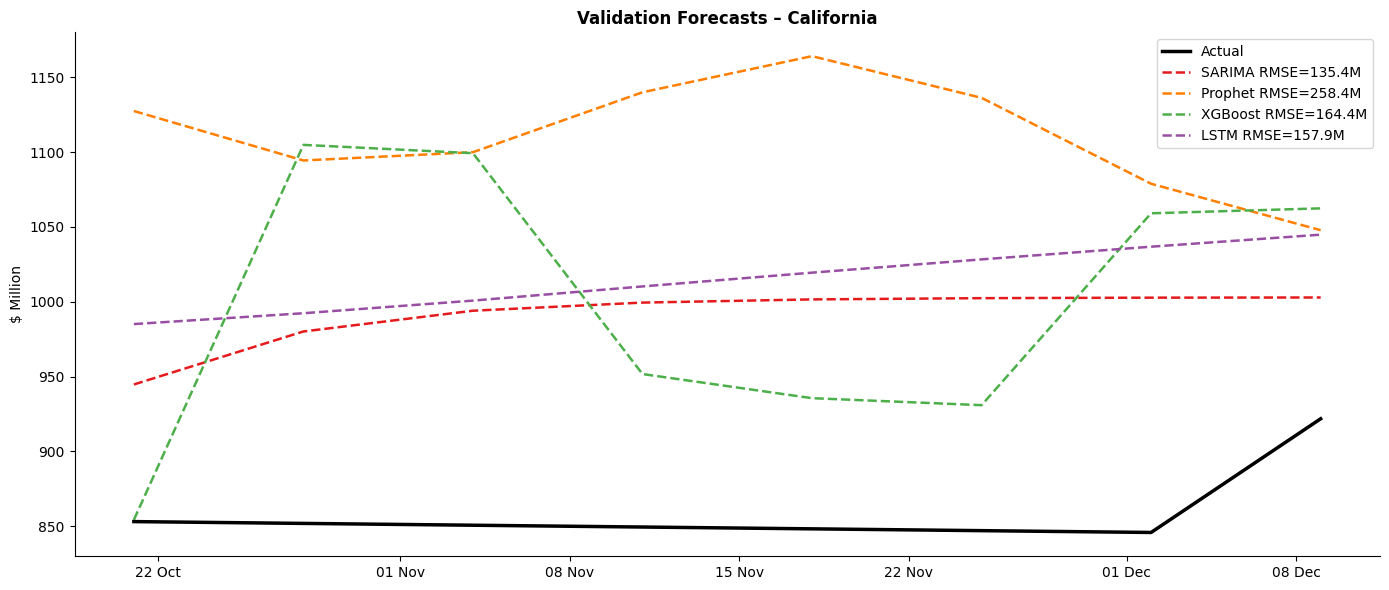

In [8]:
fig, ax = plt.subplots(figsize=(14,6))
ax.plot(val.index, val.values/1e6, 'k-', lw=2.5, label='Actual', zorder=5)
palette = {'SARIMA':'#e41a1c','Prophet':'#ff7f00','XGBoost':'#4daf4a','LSTM':'#984ea3'}
for name, preds in result.val_forecasts.items():
    rmse_v = result.all_metrics[name]['rmse']
    ax.plot(val.index, preds/1e6, '--', lw=1.8, color=palette.get(name,'gray'), label=f'{name} RMSE={rmse_v/1e6:.1f}M')
ax.set_title(f'Validation Forecasts – {STATE}', fontweight='bold'); ax.set_ylabel('$ Million')
ax.legend(); ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
plt.tight_layout(); plt.savefig('../artifacts/model_comparison.png',dpi=150); plt.show()

## 4 · Final 8-Week Forecast

In [9]:
from src.forecaster import SalesForecastingSystem
system = SalesForecastingSystem(data_path=DATA_PATH)
system.load_data()
system.train_state(STATE)
fc = system.get_forecast(STATE)
fc_df = pd.DataFrame(fc['forecast']); fc_df['date'] = pd.to_datetime(fc_df['date'])
print(f"Best model: {fc['best_model']}")
fc_df

17:12:59 - cmdstanpy - INFO - Chain [1] start processing
17:12:59 - cmdstanpy - INFO - Chain [1] done processing


Best model: LSTM


,date,sales
0,2023-12-16,8.039990e+08
1,2023-12-23,8.006856e+08
2,2023-12-30,7.972645e+08
3,2024-01-06,7.937324e+08
4,2024-01-13,7.901273e+08
5,2024-01-20,7.864889e+08
6,2024-01-27,7.828547e+08
7,2024-02-03,7.792587e+08


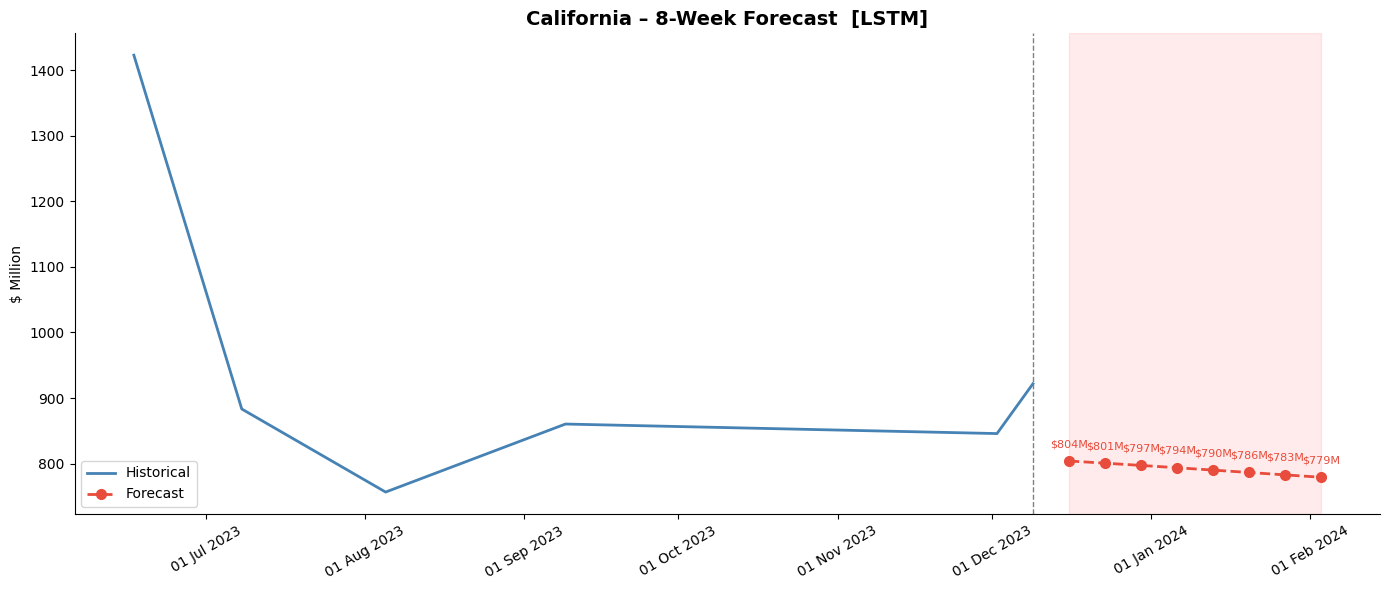

In [10]:
history = system._state_data[STATE]['full_series'].iloc[-26:]
fig, ax = plt.subplots(figsize=(14,6))
ax.plot(history.index, history.values/1e6, 'steelblue', lw=2, label='Historical')
ax.plot(fc_df['date'], fc_df['sales']/1e6, 'o--', color='#e74c3c', lw=2, ms=7, label='Forecast')
ax.axvspan(fc_df['date'].iloc[0], fc_df['date'].iloc[-1], alpha=0.08, color='red')
ax.axvline(history.index[-1], color='gray', ls='--', lw=1)
for _, row in fc_df.iterrows():
    ax.annotate(f"${row['sales']/1e6:.0f}M", xy=(row['date'], row['sales']/1e6), xytext=(0,10), textcoords='offset points', ha='center', fontsize=8, color='#e74c3c')
ax.set_title(f"{STATE} – 8-Week Forecast  [{fc['best_model']}]", fontsize=14, fontweight='bold')
ax.set_ylabel('$ Million'); ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b %Y')); plt.xticks(rotation=30)
plt.tight_layout(); plt.savefig('../artifacts/final_forecast.png',dpi=150); plt.show()

## 5 · XGBoost Feature Importances

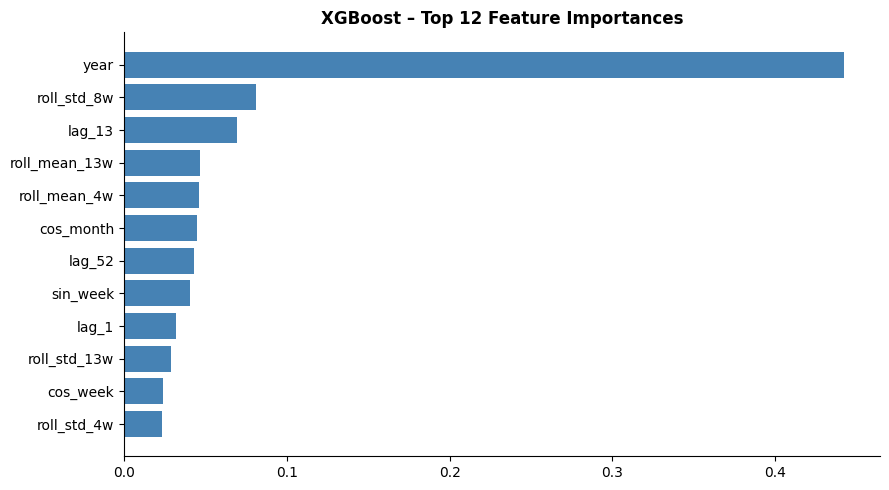

In [11]:
from src.models.xgboost_model import XGBoostForecaster
xgb = XGBoostForecaster()
xgb.fit(train)
fi = xgb.feature_importance().head(12)
fig, ax = plt.subplots(figsize=(9,5))
ax.barh(fi.index[::-1], fi.values[::-1], color='steelblue')
ax.set_title('XGBoost – Top 12 Feature Importances', fontweight='bold')
plt.tight_layout(); plt.savefig('../artifacts/xgb_feature_importance.png',dpi=150); plt.show()